In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("./assets/mpg_raw.csv")
#df = pd.read_excel('D:\DataScience-2024 scheme\CIE\Datascience_cie_grades.xlsx')
print(df.info())  # Column details

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
None


In [3]:
#To look at the Dimension of the data set
df.shape

(398, 9)

In [4]:
#To display the summary of the dataset
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [5]:
df['model_year']= pd.Categorical(df['model_year'])
print(df['model_year'])


0      70
1      70
2      70
3      70
4      70
       ..
393    82
394    82
395    82
396    82
397    82
Name: model_year, Length: 398, dtype: category
Categories (13, int64): [70, 71, 72, 73, ..., 79, 80, 81, 82]


In [6]:
# Handling missing values
df.dropna(inplace=True)  # Drop rows with NaN values

In [7]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

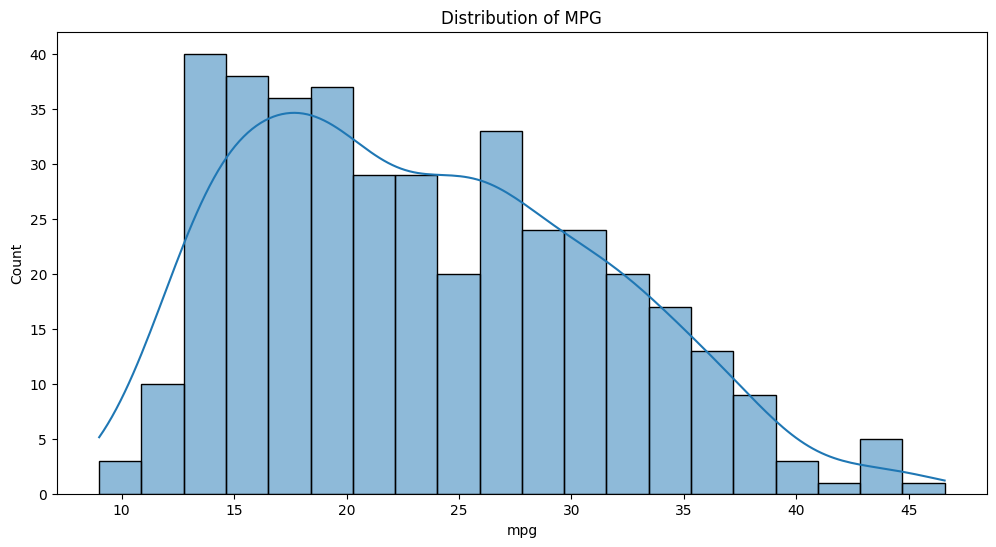

In [8]:
# Univariate Data Analysis
plt.figure(figsize=(12, 6))
sns.histplot(df['mpg'], kde=True, bins=20)
plt.title('Distribution of MPG')
plt.show()

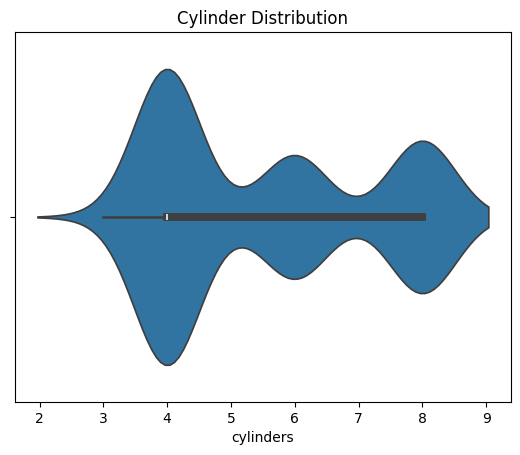

In [9]:

sns.violinplot(x=df['cylinders'])
plt.title('Cylinder Distribution')
plt.show()

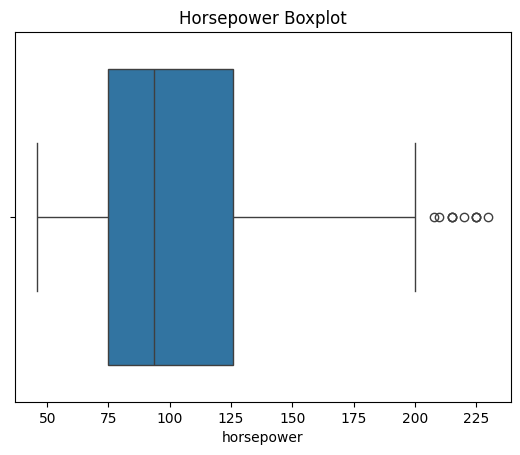

In [10]:
sns.boxplot(x=df['horsepower'])
plt.title('Horsepower Boxplot')
plt.show()

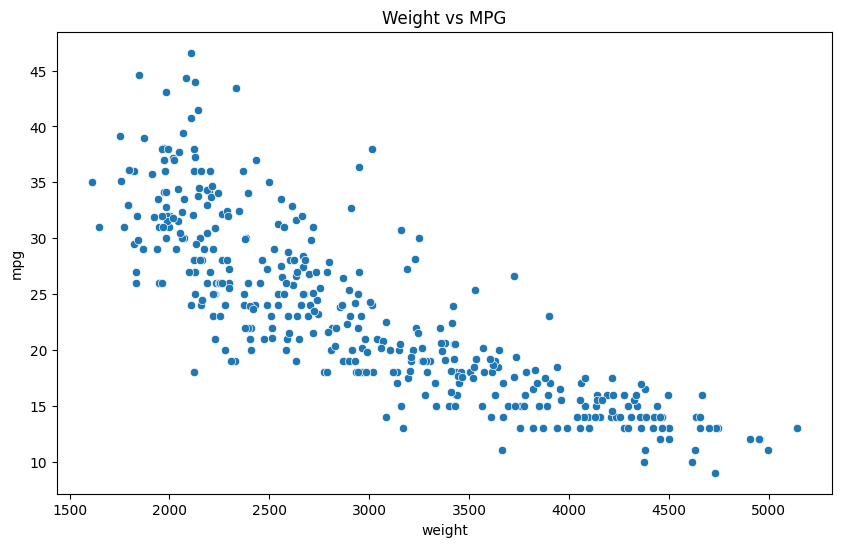

In [11]:
# Bivariate Data Analysis
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['weight'], y=df['mpg'])
plt.title('Weight vs MPG')
plt.show()

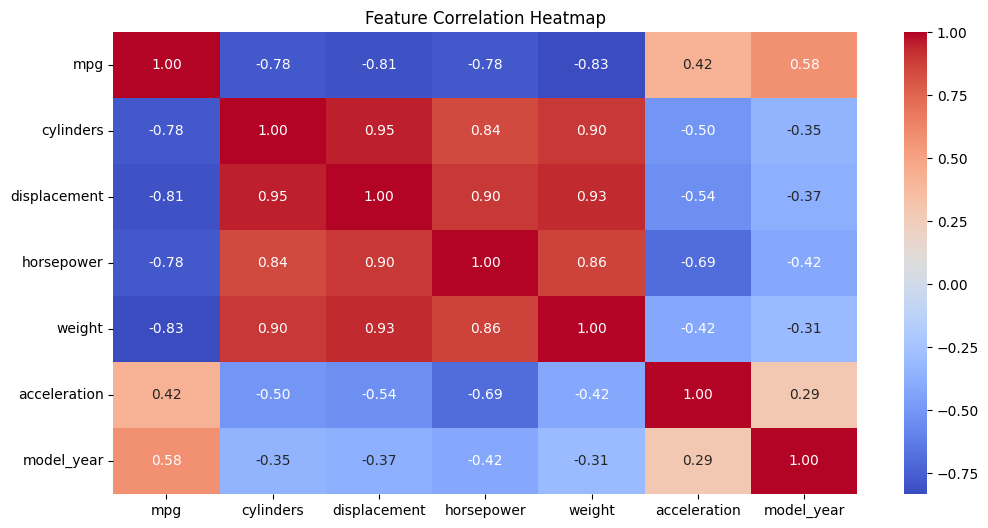

In [12]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.select_dtypes(exclude=['object']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

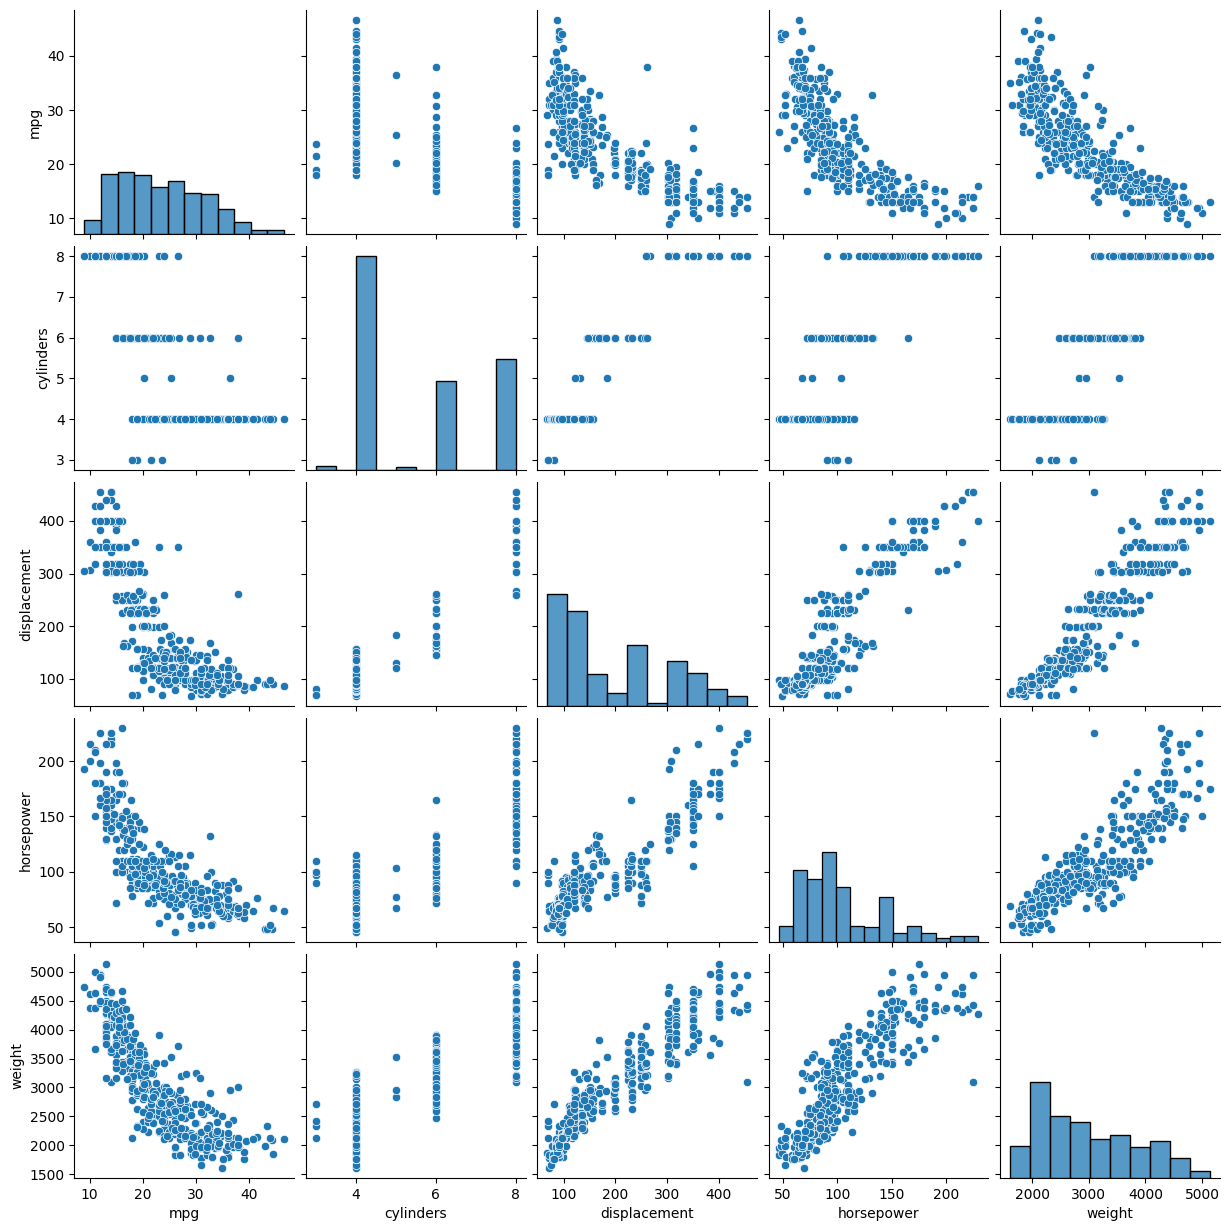

In [13]:
# Additional plots
sns.pairplot(df[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight']])
plt.show()


In [14]:
# Standardizing continuous variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
continuous_vars = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
df[continuous_vars] = scaler.fit_transform(df[continuous_vars])

In [15]:
# Standardizing continuous variables using z-score from scipy
from scipy.stats import zscore
continuous_vars = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
df[continuous_vars] = df[continuous_vars].apply(zscore)